# Taller 5: Filtros Lineales y No Lineales

## 1. Filtro promedio

### 1.1 Cree una nueva sección en su notebook
### 1.3 Cargue la imagen de trabajo med.png
### 1.4 Visualice la imagen y su histograma

In [43]:
# librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage import exposure
import time


from skimage.morphology import footprint_rectangle
from skimage.filters.rank import mean
from skimage.filters import gaussian
from scipy.ndimage import convolve


In [2]:
# path de imagenes
images_path = "images/"

os.listdir(images_path)

['IMPACT.png', 'MEB.png']

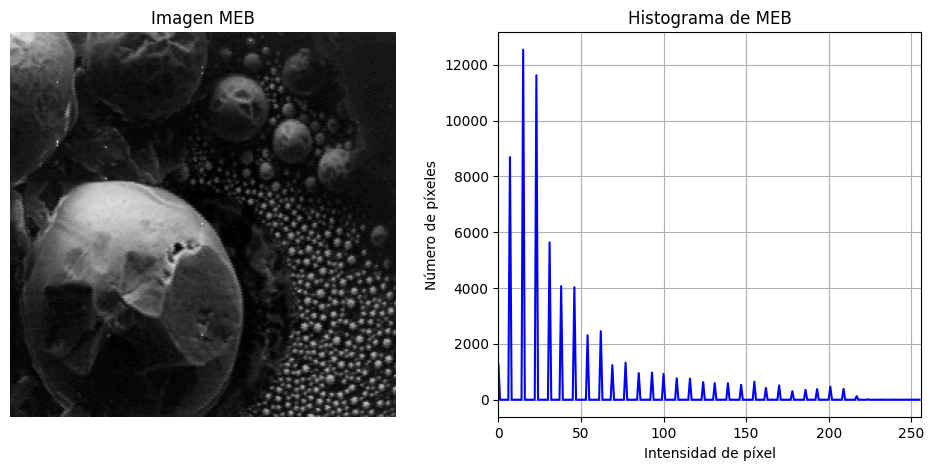

In [5]:
# cargar imagen meb.png
meb_image = cv2.imread(images_path + "MEB.png", cv2.IMREAD_GRAYSCALE)

# calcular el histograma 
hist_meb = cv2.calcHist([meb_image], [0], None, [256], [0, 256])

# visualizar
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(meb_image, cmap='gray')
plt.title("Imagen MEB")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.plot(hist_meb, color='blue')
plt.title("Histograma de MEB")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.xlim([0, 256])
plt.grid()
plt.show()

In [7]:
grises = np.unique(meb_image)
print(f"Niveles de gris diferentes: {len(grises)}")
print(f"Los niveles de gris son: {grises}")

Niveles de gris diferentes: 34
Los niveles de gris son: [  0   7  15  23  31  38  46  54  62  69  77  85  93 100 108 116 124 131
 139 147 155 162 170 178 186 193 201 209 217 224 232 240 248 255]


### 1.4 Describa su forma: ¿es continuo/discontinuo?, ¿cuántos niveles de gris diferentes tiene?, ¿cuáles son estos niveles de gris?

El histograma de la imagen MEB muestra discontinuidades entre los tonos de gris, indicando que no usa todos los niveles de gris posibles, sino solo un subconjunto de ellos. Los tonos que prevalecen se encuentran en valores de intensidad bajos, por lo que la imagen en general es de tonos oscuros. Con respecto a la forma del histograma, se observa un pico pronunciado que decrece lentamente hacia los niveles de gris más altos, recordandonos a los histogramas obtenidos cuando hay presente ruido de tipo Rayleigh.

Para determinar cuántos niveles de gris diferentes tiene la imagen, podemos usar la función `np.unique()` sobre la matriz de la imagen. Los resultados de esta función nos indican que solo 34 tonos de gris son presentados en la imagen, siendo estos los siguientes: [  0   7  15  23  31  38  46  54  62  69  77  85  93 100 108 116 124 131 139 147 155 162 170 178 186 193 201 209 217 224 232 240 248 255]



### 1.5 Partiendo del histograma, deduzca con cuántos bits ha sido numerizada esta imagen.

A partir del análisis del histograma y de los niveles de gris proporcionados, se deduce que la imagen fue originalmente numerizada con 5 bits ($2^5 = 32$ niveles teóricos), ya que el conteo de 34 niveles se aproxima significativamente a esta resolución y el paso de cuantización observado (la diferencia entre niveles consecutivos) es predominantemente de 8 unidades ($256 / 32 = 8$). Esta estructura de "peine" en el histograma, donde los niveles están separados por huecos de información, confirma que la imagen sufrió una expansión de contraste para cubrir el rango de 0 a 255; los dos niveles adicionales (34 en lugar de 32) son artefactos típicos del redondeo matemático o del tratamiento de los valores extremos durante dicho mapeo lineal, pero la resolución radiométrica real permanece limitada por la cuantización original de 5 bits.

Niveles de gris en la imagen reducida a 5 bits: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
Niveles de gris diferentes en la imagen reducida a 5 bits: 32
Niveles de gris en la imagen recuperada: [  0   8  16  24  32  40  48  56  64  72  80  88  96 104 112 120 128 136
 144 152 160 168 176 184 192 200 208 216 224 232 240 248]
Niveles de gris diferentes en la imagen original: 34


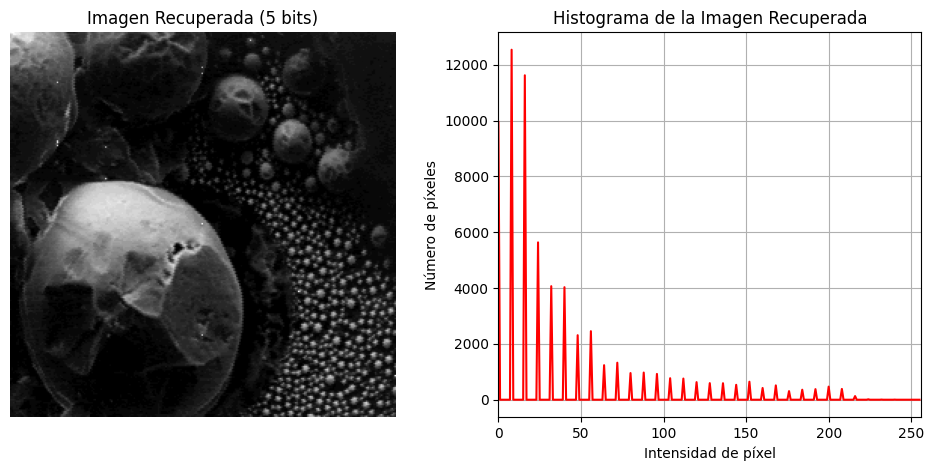

In [10]:
# 2. Reducir a 5 bits (32 niveles)
img_5bits = np.floor(meb_image / 8).astype(np.uint8)

# 3. Volver a expandir a 8 bits para visualizar
img_recuperada = img_5bits * 8
hist_recuperada = cv2.calcHist([img_recuperada], [0], None, [256], [0, 256])

print(f"Niveles de gris en la imagen reducida a 5 bits: {np.unique(img_5bits)}")
print(f"Niveles de gris diferentes en la imagen reducida a 5 bits: {len(np.unique(img_5bits))}")
print(f"Niveles de gris en la imagen recuperada: {np.unique(img_recuperada)}")
print(f"Niveles de gris diferentes en la imagen original: {len(np.unique(meb_image))}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_recuperada, cmap='gray')
plt.title("Imagen Recuperada (5 bits)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.plot(hist_recuperada, color='red')
plt.title("Histograma de la Imagen Recuperada")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.xlim([0, 256])
plt.grid()
plt.show()

### 1.6 Aplique un filtro promedio utilizando una máscara de tamaño 3x3 a esta imagen. Cualitativamente, ¿cómo es la imagen resultado?

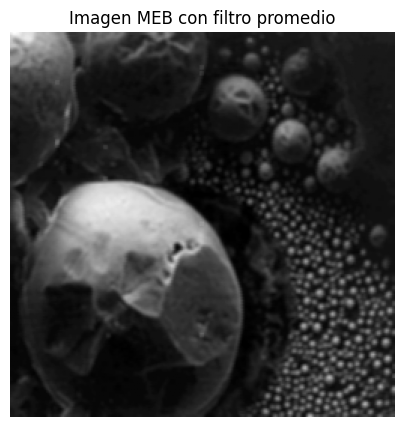

In [13]:
# aplicar filtro promedio
mean_meb = mean(meb_image, footprint_rectangle((3,3)))

# visualizar
plt.figure(figsize=(8, 5))
plt.imshow(mean_meb, cmap='gray')
plt.title("Imagen MEB con filtro promedio")
plt.axis('off')
plt.show()

El filtro promedio aplicado a la imagen calcula con una convolución el valor promedio de los NxN píxeles vecinos por cada píxel de la imagen, resultando en una imagen suavizada que al ojo se torna borrosa en los contornos.

### 1.7 Visualice el histograma de esta nueva imagen, y compárelo con el histograma de la imagen original (forma general, altura de los picos, ...).

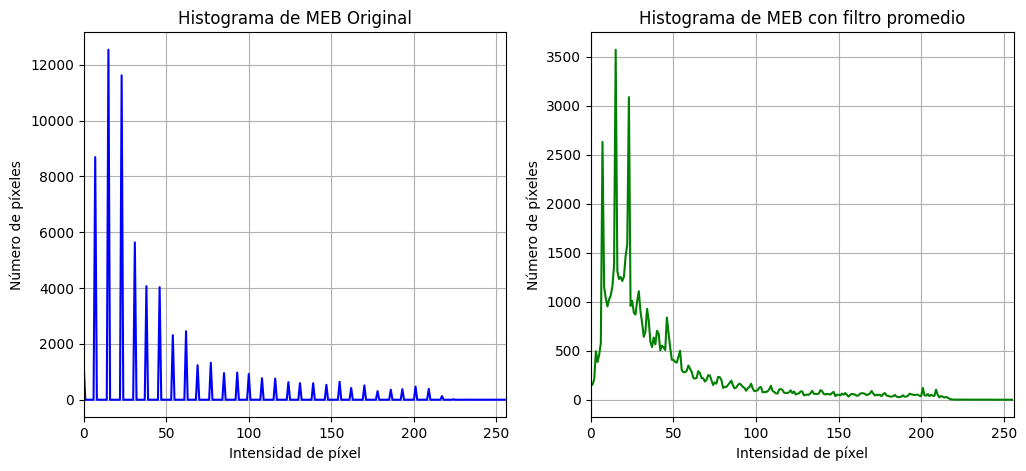

In [16]:
# histograma de la imagen con filtro promedio
hist_mean_meb = cv2.calcHist([mean_meb], [0], None, [256], [0, 256])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_meb, color='blue')
plt.title("Histograma de MEB Original")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.xlim([0, 256])
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(hist_mean_meb, color='green')
plt.title("Histograma de MEB con filtro promedio")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Número de píxeles")
plt.xlim([0, 256])
plt.grid()
plt.show()

In [17]:
print(f"Niveles de gris diferentes en la imagen con filtro promedio: {len(np.unique(mean_meb))}")

Niveles de gris diferentes en la imagen con filtro promedio: 231


El histograma resultante de la imagen filtrada con el filtro promedio muestra una distribución más uniforme de los niveles de gris, con una reducción significativa del número de píxeles en los picos que se encontraban en el histograma original. Esto se produce debido a que calcular el promedio entre los píxeles vecinos suaviza las transiciones abruptas entre los niveles de gris. Notamos que además pasa de ser un histograma de aparencia discontinua a uno más continuo. Lo podemos comprobar obteniendo el número de niveles de gris diferentes en la imagen filtrada, el cual es de 231 valores.

### 1.8 Calcule la imagen de diferencia con la original. Justifique el resultado obtenido (¿en cuáles regiones de la imagen son visibles las diferencias?, ¿por qué?).

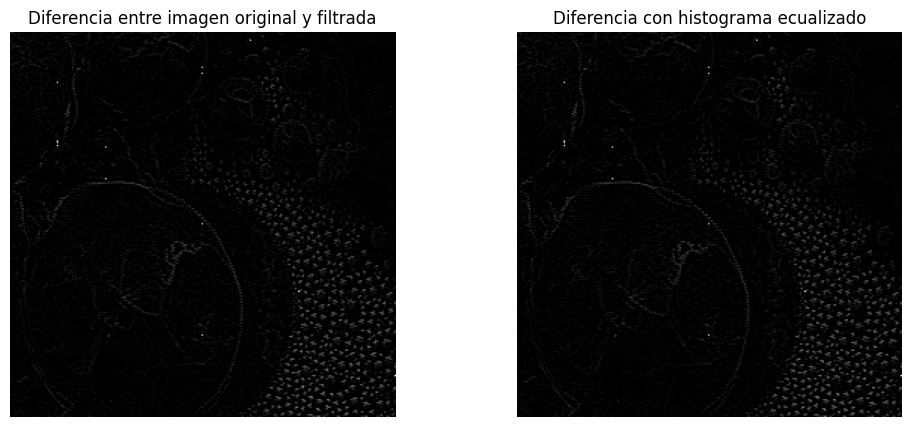

In [38]:
# original - filtrada
substraction = cv2.subtract(meb_image, mean_meb)

# ecualización del histograma de la imagen diferencia para ver mejor el contraste
rescaled_img = cv2.equalizeHist(substraction)
rescaled_img = exposure.rescale_intensity(substraction, in_range=(substraction.min(), substraction.max()), out_range=(0, 255)).astype(np.uint8)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(substraction, cmap='gray')
plt.title("Diferencia entre imagen original y filtrada")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rescaled_img, cmap='gray')
plt.title("Diferencia con histograma ecualizado")
plt.axis('off')
plt.show()

Podemos observar que al calcular la diferencia entre la imagen original y la imagen filtrada, las diferencias más visibles se encuentran en las regiones no uniformas de la imagen, como los bordes o las distintas texturas presentes. Esto se debe, nuevamente, a que el filtro promedio suaviza las transiciones entre los niveles de gris, haciendo que tanto bordes como texturas pierdan definición y se vuelvan más borrosos. En contraste, las regiones más uniformes de la imagen no presentan diferencias tan marcadas, ya que el valor promedio de los píxeles vecinos en estas áreas no varía tanto respecto a los valores originales.

### 1.9 Ahora filtre la imagen original con un filtro promedio utilizando una máscara de tamaño 5x5. Paralelamente, filtre la imagen original, aplicando consecutivamente sobre esta, dos filtros promedio de tamaño 3x3. Haga una evaluación visual de los resultados: ¿las dos imágenes obtenidas son idénticas? ¿por qué? ¿cuál de los dos tratamientos suprime mejor los cambios de nivel de gris de la imagen?

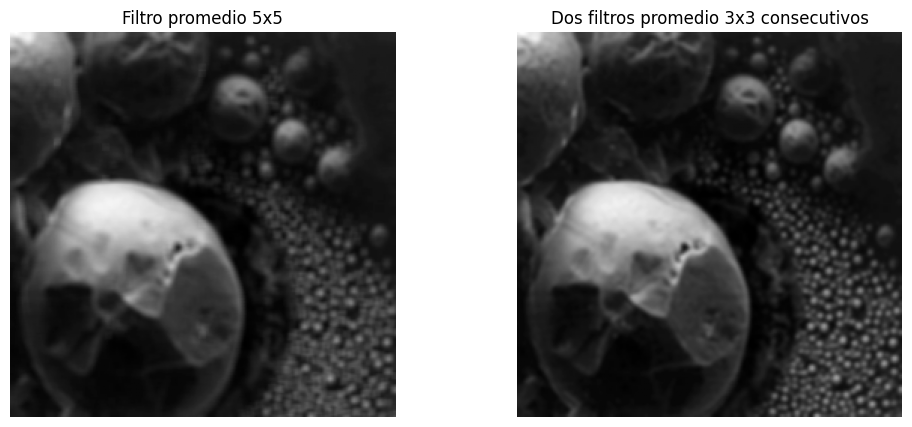

Los filtros son iguales? False


In [27]:
# filtro promedio con máscara 5x5
mean_meb_5x5 = mean(meb_image, footprint_rectangle((5,5)))

# aplicar dos filtros promedio de tamaño 3x3 consecutivamente
mean_meb_3x3_1 = mean(meb_image, footprint_rectangle((3,3)))
mean_meb_3x3_2 = mean(mean_meb_3x3_1, footprint_rectangle((3,3)))

# visualizar filtro 5x5 y dos filtros 3x3 consecutivos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(mean_meb_5x5, cmap='gray')
plt.title("Filtro promedio 5x5")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mean_meb_3x3_2, cmap='gray')
plt.title("Dos filtros promedio 3x3 consecutivos")
plt.axis('off')
plt.show()

print(f"Los filtros son iguales? {np.array_equal(mean_meb_5x5, mean_meb_3x3_2)}")

Las imágenes obtenidas al aplicar un filtro promedio de tamaño 5x5 y al aplicar consecutivamente dos filtros promedio de 3x3 no son idénticas: si bien ambos tratamientos suavizan la imagen, el filtro de 5x5 genera un efecto más agresivo, resultando en contornos más borrosos y una mayor pérdida de detalles. Esto se debe a que el filtro de 5x5 asigna el mismo peso a todos los píxeles de un área mayor, lo que reduce drásticamente la variabilidad local y 'aplana' la imagen por igual. En contraste, aplicar dos filtros de 3x3 de forma consecutiva suaviza la imagen de manera más gradual; aunque el área total afectada termina siendo de 5x5 (pues el primer paso de 3x3 hace que los píxeles tomen infomación de sus 8 vecinos, al pasar el segundo filtro la información de los vecinos tendrá la información de sus vecinos más cercanos, afectando una cuadrícula de 5x5), el proceso por etapas hace que los píxeles centrales conserven una mayor influencia en el promedio final. De este modo, la variación de los valores ocurre en una magnitud menor y más controlada, logrando un difuminado que respeta mejor la estructura original de la imagen en comparación con el filtro de 5x5.

Teniendo estas consideraciones en cuenta, aplicar un filtro promedio de 5x5 suprime mejor los cambios de niveles de gris, con la contraparte de que también borra más detalles, mientras que aplicar dos filtros de 3x3 consecutivos ofrece un equilibrio entre suavizado y conservación de detalles, aunque con una supresión de cambios de niveles de gris menos pronunciada.

### 1.10 Convolucionar una imagen dos veces con una misma máscara equivale a hacer una sola convolución con otra máscara, obtenida por convolución de la máscara inicial con ella misma. ¿Cuál es entonces la máscara resultante de la convolución de la máscara del filtro promedio 3x3 con ella misma? ¿Cómo es la máscara del filtro promedio 5x5? Con base en la forma de estas dos máscaras, justifique los resultados visuales obtenidos en el punto anterior.

La máscara resultante de la convolución de la máscara del filtro promedio 3x3 con ella misma es una máscara 5x5 calculada de la siguiente forma:
1. Añadir un padding a la máscara original de 3x3 para convertirla en una máscara de 5x5, rellenando con ceros los valores fuera de la máscara original:
```
0 0 0 0 0
0 1 1 1 0
0 1 1 1 0
0 1 1 1 0
0 0 0 0 0
```
2. Convolucionar esta máscara con ella misma, lo que implica calcular el valor de cada posición de la nueva máscara 5x5 sumando los productos de los valores correspondientes de las dos máscaras. El resultado de esta convolución es la siguiente máscara 5x5 (los valores del padding, al pasar por la máscara, es como si tuvieran valores 0 alrededor):
```
1 2 3 2 1
2 4 6 4 2
3 6 9 6 3
2 4 6 4 2
1 2 3 2 1
```
3. Al usar la máscara obtenida, se normaliza dividiendo entre 81 (la suma de todos los valores de la máscara).

Por otro lado, la máscara del filtro promedio 5x5 es una matriz de 1s, normalizada dividiendo entre 25:
```
1 1 1 1 1
1 1 1 1 1
1 1 1 1 1
1 1 1 1 1
1 1 1 1 1
```

Notamos entonces que los resultados obtenidos son muy diferentes, pues en la máscara obtenida al convolucionar la máscara de 3x3 con ella misma, los píxeles centrales tienen un peso mucho mayor que los periféricos, haciendo que el suavizado sea más gradual y respetoso con la estructura original de la imagen, mientras que en la máscara del filtro promedio 5x5, todos los píxeles tienen el mismo peso, lo que genera un efecto de suavizado más agresivo y uniforme, resultando en una mayor pérdida de detalles y una imagen más borrosa.


### 1.11 Por último, filtre la imagen original con un filtro promedio utilizando una máscara de tamaño 25x25. Haga una evaluación visual del resultado: ¿qué objetos de la imagen original se conservaron?¿qué sucedió con las estructuras pequeñas presentes en la imagen original?¿por qué?

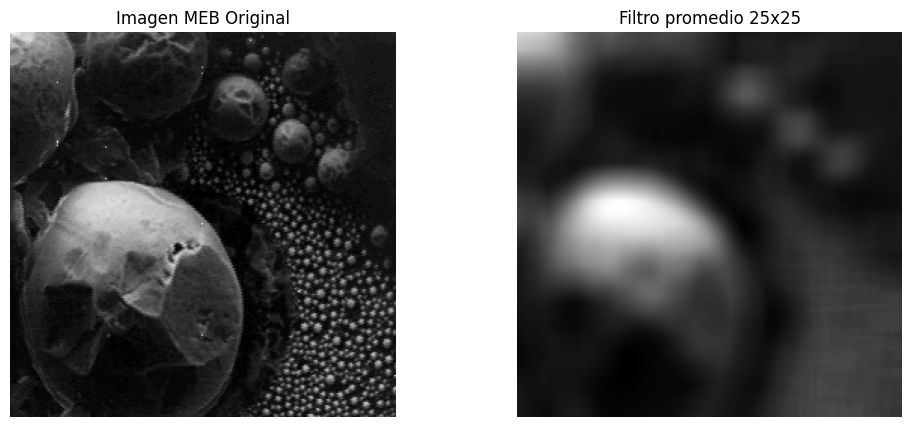

In [28]:
# filtro promedio tamaño 25x25
mean_meb_25x25 = mean(meb_image, footprint_rectangle((25,25)))

# visualizar imagen original y filtro
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(meb_image, cmap='gray')
plt.title("Imagen MEB Original")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mean_meb_25x25, cmap='gray')
plt.title("Filtro promedio 25x25")
plt.axis('off')
plt.show()

Al aplicar el filtro promedio con un tamaño de máscara de 25x25, se conservan únicamente las estructuras más grandes de la imagen original. Esto sucede porque el filtro de 25x25 toma el promedio de un área mucho mayor al de los detalles pequeños, por lo que al calcular el promedio, estos detalles se pierden completamente con su entorno. En general, el tamaño de la máscara determina qué detalles se conservan según su tamaño: mientras más grande sea la máscara, más detalles pequeños se perderán, y solo las estructuras grandes serán visibles.

### 1.12 Cargue ahora la imagen impact.png

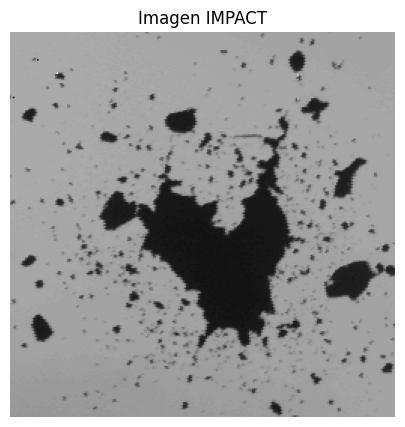

In [29]:
impact_image = cv2.imread(images_path + "IMPACT.png", cv2.IMREAD_GRAYSCALE)

# visualizar imagen impact
plt.figure(figsize=(8, 5))
plt.imshow(impact_image, cmap='gray')
plt.title("Imagen IMPACT")
plt.axis('off')
plt.show()

### 1.13 Aplique a esta imagen un filtro promedio con una máscara de tamaño 5x5 usando una convolución. Visualice el resultado.

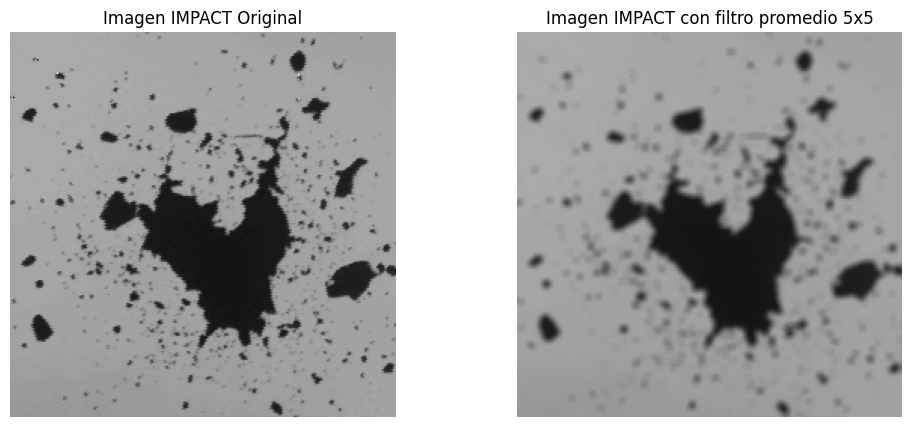

In [31]:
# filtro promedio con máscara 5x5
mean_impact_5x5 = mean(impact_image, footprint_rectangle((5,5)))

# visualizar imagen original y filtro
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(impact_image, cmap='gray')
plt.title("Imagen IMPACT Original")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mean_impact_5x5, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen IMPACT con filtro promedio 5x5")
plt.axis('off')
plt.show()

### 1.14 Ahora aplique a la imagen original un filtro gaussiano con una máscara de tamaño 5x5 usando una convolución. Visualice el resultado.

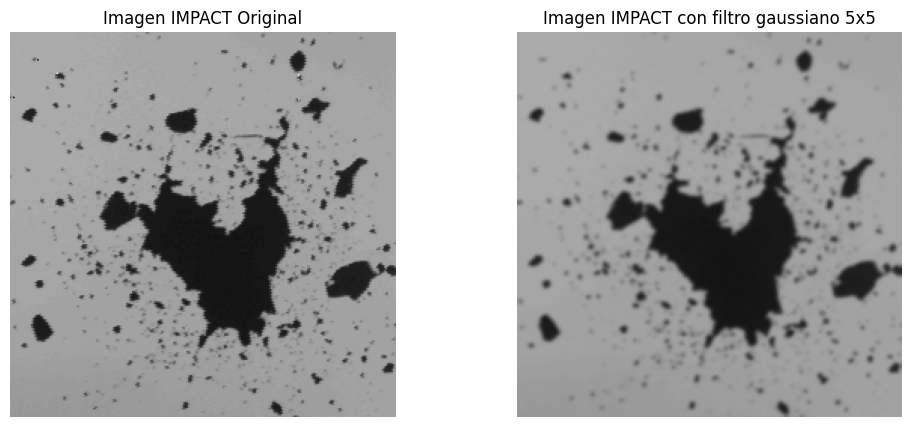

In [33]:
# filtro gaussiano con máscara 5x5
impact_gaussian = cv2.GaussianBlur(impact_image, (5, 5), 0) # sigma=0 para que se calcule automáticamente a partir del tamaño de la máscara

# visualizar imagen original y filtro gaussiano
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(impact_image, cmap='gray')
plt.title("Imagen IMPACT Original")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(impact_gaussian, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen IMPACT con filtro gaussiano 5x5")
plt.axis('off')
plt.show()

### 1.15 Calcule la diferencia de los resultados de los dos filtros. Visualice el resultado. Justifique el resultado obtenido (¿en cuáles regiones de la imagen son visibles las diferencias?, ¿por qué?...).

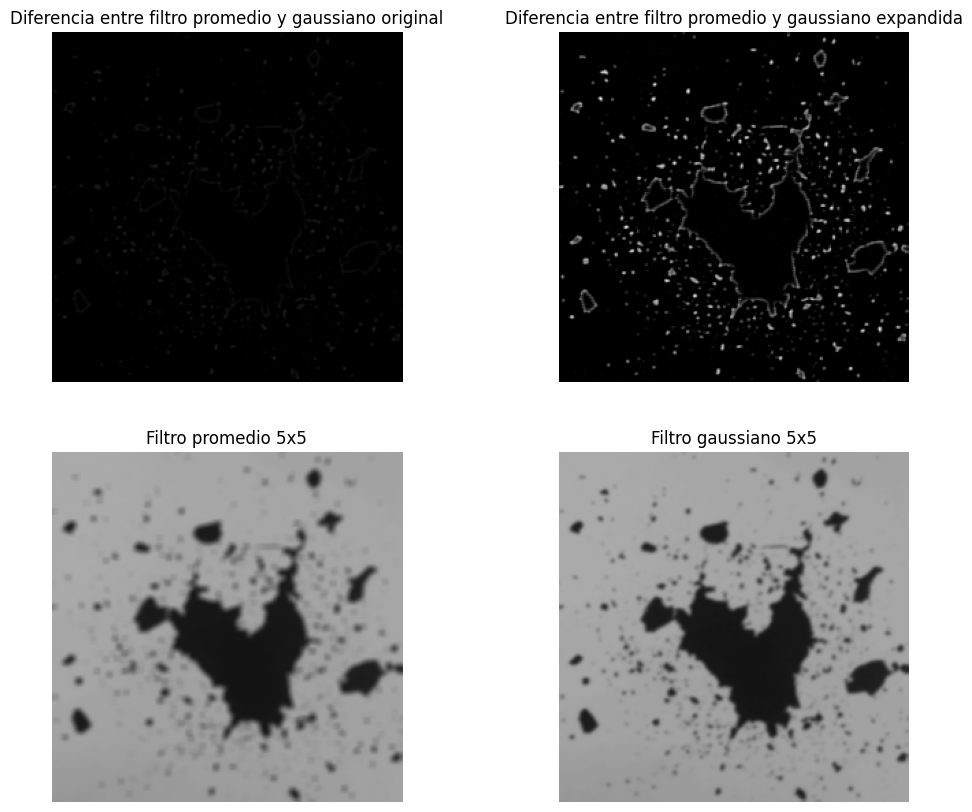

In [40]:
# diferencia entre filtro promedio y gaussiano
substraction = cv2.subtract(mean_impact_5x5, impact_gaussian)

# aplicar una expansión para ver mejor
substraction_expanded = exposure.rescale_intensity(substraction, in_range=(substraction.min(), substraction.max()), out_range=(0, 255)).astype(np.uint8)

# visualizar la diferencia
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(substraction, cmap='gray', vmin=0, vmax=255)
plt.title("Diferencia entre filtro promedio y gaussiano original")
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(substraction_expanded, cmap='gray', vmin=0, vmax=255)
plt.title("Diferencia entre filtro promedio y gaussiano expandida")
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(mean_impact_5x5, cmap='gray', vmin=0, vmax=255)
plt.title("Filtro promedio 5x5")
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(impact_gaussian, cmap='gray', vmin=0, vmax=255)
plt.title("Filtro gaussiano 5x5")
plt.axis('off')
plt.show()

Las diferencias son principalmente visibles en los contornos de la figura presente en la imagen. Esto se debe a que el filtro gaussiano, a diferencia del filtro promedio, asigna pesos mayores a los píxeles cercanos al centro de la máscara, y pesos menores a los píxeles a medida que se alejan del centro. Esto hace que el filtro gaussiano preserve de mejor manera loso bordes y detalles, como se ve en las imagenes obtenidas y se confirma en la imagen de diferencias.

### 1.16 ¿En qué casos (características de las imágenes) preferiría utilizar un filtro promedio a un filtro gaussiano y visceversa?

El filtro promedio es preferible donde se desea un suavizado rápido y general, sin necesidad de preservar detalles finos. Por otro lado, el filtro gaussiano es más adecuado cuando se busca suavizar la imagen mientras que se conservan los bordes y detalles importantes, pues su asignación de pesos respeta de mejor manera la estructura de la imagen. Como contraparte, el filtro gaussiano es computacionalmente más costoso que el filtro promedio, por lo que en situaciones donde se necesita un procesamiento rápido, el filtro promedio es preferible.

## 2. Filtros lineales separables

### 2.1 Cree una nueva sección en su notebook
### 2.2 Cargue la imagen meb.png y remuestréela para obtener una imagen de tamaño 2048x2048.

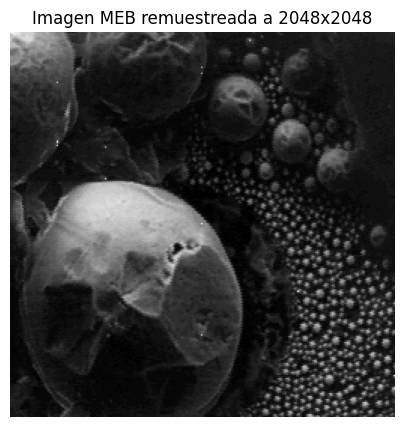

In [69]:
# cargar imagen meb
meb_image = cv2.imread(images_path + "MEB.png", cv2.IMREAD_GRAYSCALE)

# remuestrear
meb_resized =  cv2.resize(meb_image, (2048,2048), interpolation=cv2.INTER_NEAREST)

# visualizar imagen remuestreada
plt.figure(figsize=(8, 5))
plt.imshow(meb_resized, cmap='gray')
plt.title("Imagen MEB remuestreada a 2048x2048")
plt.axis('off')
plt.show()

### 2.3 Aplique un filtros promedio de 3x3 a la imagen usando una convolución. Realice varias ejecuciones y mida el tiempo de las mismas.

In [70]:
# fijamos el número de ejecuciones (para este y demás experimentos) y el kernel ya normalizado
num_ejecuciones = 100
kernel = (1/9)*np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]])

times_convolve = []
for _ in range(num_ejecuciones):
    start_time = time.time()
    mean_meb_convolve = convolve(meb_resized, kernel, mode='constant', cval=0.0)
    end_time = time.time()
    times_convolve.append(end_time - start_time)

print(f"Tiempo promedio de ejecución con convolve kernel 3x3: {np.mean(times_convolve):.4f} segundos")

Tiempo promedio de ejecución con convolve kernel 3x3: 0.0189 segundos


### 2.4 Aplique un filtro promedio de 3x1 sobre la imagen de trabajo y luego un filtro promedio de 1x3 usando una convolución. Realice varias ejecuciones y mida el tiempo de las mismas.

In [82]:
kernel_3x1 = (1/3)*np.array([[1],
                             [1],
                             [1]])
kernel_1x3 = (1/3)*np.array([[1, 1, 1]])

times_3x1 = []
times_1x3 = []

for _ in range(num_ejecuciones):
    start_time = time.time()
    mean_meb_3x1 = convolve(meb_resized, kernel_3x1, mode='constant', cval=0.0)
    end_time = time.time()
    times_3x1.append(end_time - start_time)

    start_time = time.time()
    mean_meb_3x1_w_1x3 = convolve(mean_meb_3x1, kernel_1x3, mode='constant', cval=0.0)
    end_time = time.time()
    times_1x3.append(end_time - start_time)

print(f"Tiempo promedio de ejecución con kernel 3x1: {np.mean(times_3x1):.4f} segundos")
print(f"Tiempo promedio de ejecución con kernel 1x3: {np.mean(times_1x3):.4f} segundos")

Tiempo promedio de ejecución con kernel 3x1: 0.0126 segundos
Tiempo promedio de ejecución con kernel 1x3: 0.0127 segundos


### 2.5 Grafique el resultado comparativo de los tiempos de ejecución para los puntos anteriores.

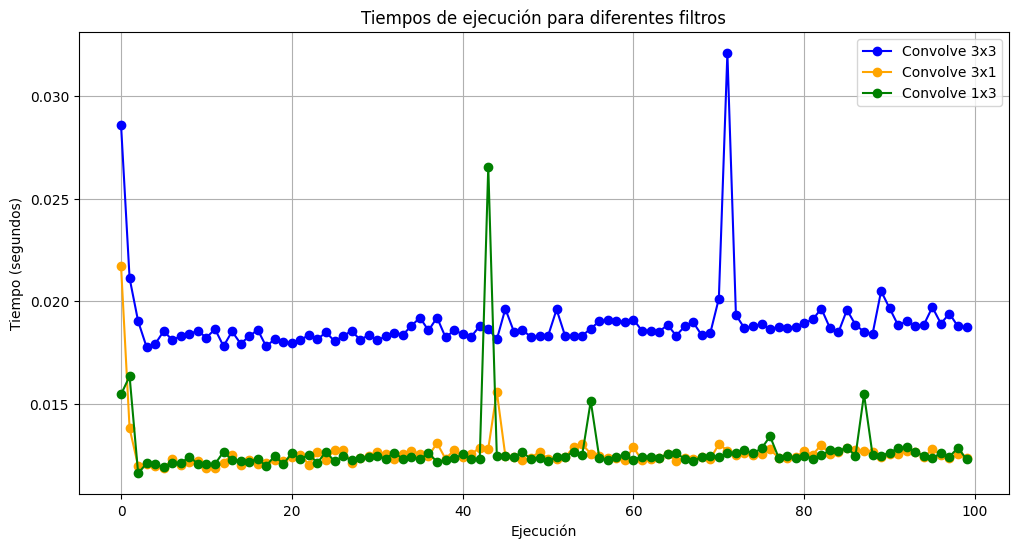

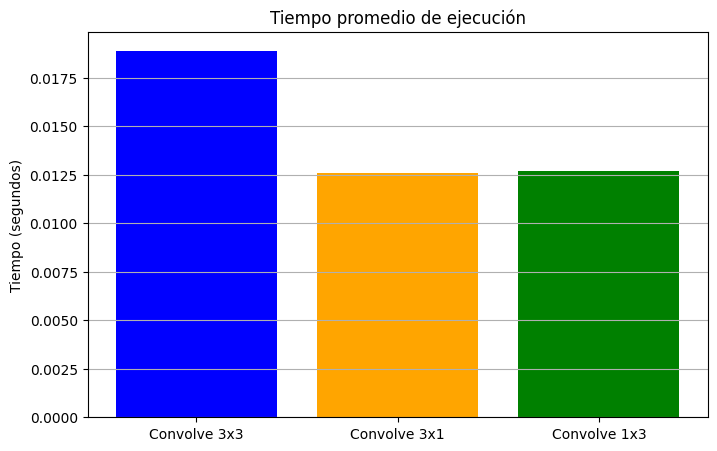

In [83]:
# plotear gráficos para cada ejecución
plt.figure(figsize=(12, 6))
plt.plot(times_convolve, label='Convolve 3x3', marker='o', color='blue')
plt.plot(times_3x1, label='Convolve 3x1', marker='o', color='orange')
plt.plot(times_1x3, label='Convolve 1x3', marker='o', color='green')
plt.title("Tiempos de ejecución para diferentes filtros")
plt.xlabel("Ejecución")
plt.ylabel("Tiempo (segundos)")
plt.legend()
plt.grid()
plt.show()

# plotear barras con el tiempo promedio
plt.figure(figsize=(8, 5))
labels = ['Convolve 3x3', 'Convolve 3x1', 'Convolve 1x3']
times_avg = [np.mean(times_convolve), np.mean(times_3x1), np.mean(times_1x3)]
plt.bar(labels, times_avg, color=['blue', 'orange', 'green'])
plt.title("Tiempo promedio de ejecución")
plt.ylabel("Tiempo (segundos)")
plt.grid(axis='y')
plt.show()

### 2.6 Efectúe una sustracción de estas imágenes para corroborar el resultado Las dos imágenes resultantes, ¿son idénticas? 

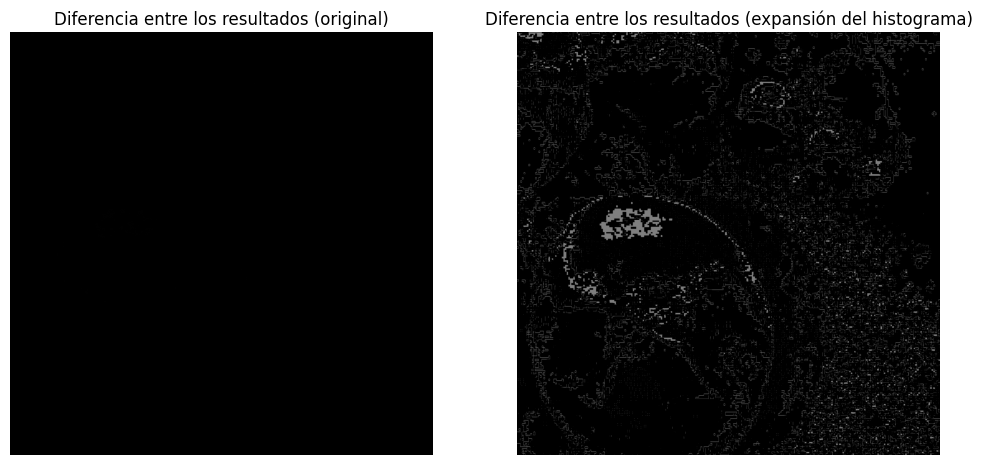

In [ ]:
# sustracción de las imágenes obtenidas 2 a 2
diff = cv2.subtract(mean_meb_convolve, mean_meb_3x1_w_1x3)

# expandir el histograma
diff_expanded = exposure.rescale_intensity(diff, in_range=(diff.min(), diff.max()), out_range=(0, 255)).astype(np.uint8)

# visualizar las diferencias
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(diff, cmap='gray', vmin=0, vmax=255)
plt.title("Diferencia entre los resultados (original)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(diff_expanded, cmap='gray', vmin=0, vmax=255)
plt.title("Diferencia entre los resultados (expansión del histograma)")
plt.axis('off')
plt.show()


REVISAR!! DEBERÍAN SER IGUALES

### 2.7 Revise la siguiente explicación en separabilidad de filtros lineales. Explique la diferencia de los tiempos de ejecución determinando el número de operaciones elementales (SUMA, RESTA) efectuadas por las dos versiones del filtro. 

FALTA

### 2.8 Calcule la duración de ejecución que se debería obtener con un filtro promedio 10 veces más grande (es decir de tamaño 30x30). Verifique este resultado experimentalmente e intente explicar el tiempo de cálculo observado (pensando en los métodos de optimización utilizables con el filtro promedio separable).